# 04 — Estratificación de Riesgo (4 niveles)

**Fase 1D.** Transformamos la probabilidad calibrada en niveles clínicos **Bajo / Moderado / Alto / Muy Alto**. NO se asumen umbrales arbitrarios: se comparan 4 métodos y se elige el que mejor **separa** los grupos.

In [1]:
# --- Setup: rutas y utilidades de presentación ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

BR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BR / "src"))
sys.path.insert(0, str(BR.parent / "src"))
from predia_brfss import config, codebook

RES = BR / "results"
def show(p, w=None):
    display(Image(filename=str(p), width=w))
def table(csv, **kw):
    return pd.read_csv(csv, **kw)
def load(j):
    return json.load(open(j))
pd.set_option("display.max_columns", 40)
print("Entorno listo:", BR)


Entorno listo: /home/wowo/Descargas/predia/ml-research/brfss


## Los 4 métodos
1. **Percentiles poblacionales** (P50/P80/P95) — tamaños por cola.
2. **Cuartiles** (Q1/Q2/Q3) — grupos de tamaño igual.
3. **Sensibilidad clínica** (ROC): exclusión sens≥0.90 · Youden · inclusión espec≥0.90.
4. **Cost-sensitive** — umbral de Bayes para ratios de costo FN:FP (10/4/1.5).

In [2]:
strat = load(RES/'risk'/'stratification.json')
table(RES/'risk'/'method_comparison.csv')

,method,thresholds,band_sizes,min_band_size,monotonic,prev_ratio_extreme,eta_squared,band_prevalences
0,percentiles,"[0.07476635277271271, 0.2406417280435562, 0.47...","[25299, 14671, 8134, 2632]",2632,True,20.49,0.1790,"[0.0267, 0.1489, 0.3402, 0.5475]"
1,quartiles,"[0.017834065482020378, 0.07476635277271271, 0....","[10295, 15004, 11874, 13563]",10295,True,52.86,0.1569,"[0.0067, 0.0405, 0.1337, 0.3543]"
2,clinical,"[0.0899, 0.1414, 0.3322]","[25513, 4929, 12644, 7650]",4929,True,16.18,0.1742,"[0.0271, 0.1023, 0.1989, 0.439]"
3,cost_sensitive,"[0.0909, 0.2, 0.4]","[26147, 11921, 7831, 4837]",4837,True,17.25,0.1804,"[0.0286, 0.1419, 0.2859, 0.4941]"


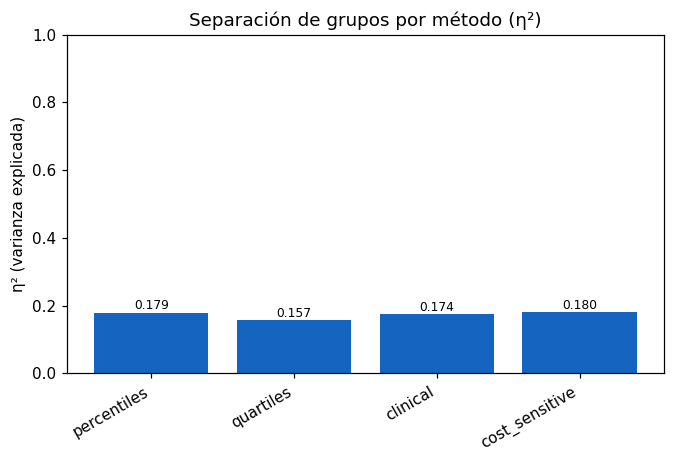

In [3]:
show(RES/'risk'/'method_separation.png')

## Método elegido y bandas resultantes

In [4]:
print('Método elegido:', strat['chosen_method'])
print('Umbrales:', strat['chosen_thresholds'])
print('Regla:', strat['selection_rule'])
bands = pd.DataFrame(strat['methods'][strat['chosen_method']]['bands'])
bands

Método elegido: cost_sensitive
Umbrales: [0.0909, 0.2, 0.4]
Regla: monótono en prevalencia + bandas >=1% población + máximo η²


,band,action,score_range,n,pct_population,observed_prevalence
0,Bajo,Seguimiento normal,"[0.0, 0.0909]",26147,51.54,0.0286
1,Moderado,Educación y cambios de hábitos,"[0.0909, 0.2]",11921,23.50,0.1419
2,Alto,Evaluación clínica prioritaria,"[0.2, 0.4]",7831,15.43,0.2859
3,Muy Alto,Referencia médica inmediata,"[0.4, 1.0]",4837,9.53,0.4941


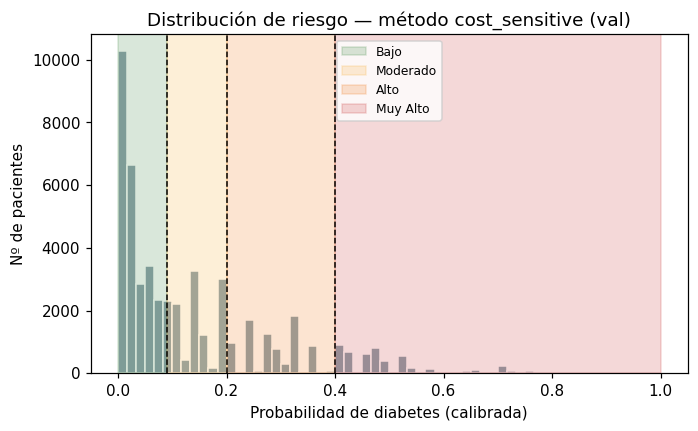

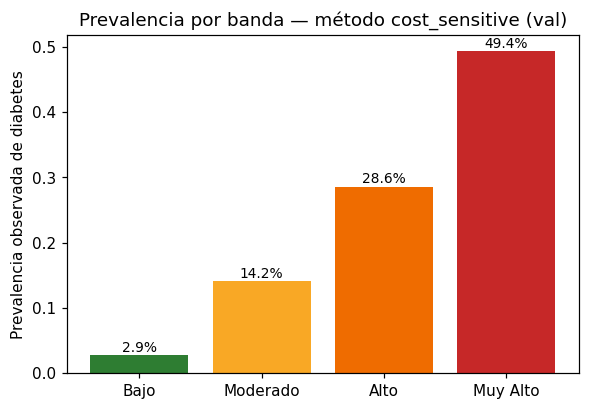

In [5]:
show(RES/'risk'/'risk_distribution.png')
show(RES/'risk'/'band_prevalence_val.png')

### Conclusiones Fase 1D
- El método elegido maximiza η² (varianza del desenlace explicada por la banda) manteniendo **monotonía** y bandas no triviales.
- Cada banda lleva asociada una **acción clínica** (seguimiento → educación → evaluación prioritaria → referencia inmediata).
- La validez de estas bandas se confirma en *test* (NB 06).